# Final Evaluation — MEF-LSTM Itajaí-Açu

**Objective**: Compare the baseline (NSE t+7 = 0.119) with the best model (NSE t+7 = 0.474)  
analysing the most relevant historical flood events in the basin.

## Structure
1. [Load results](#load) — reads zarr from all experiments
2. [Comparison table](#table) — NSE, KGE, PBIAS for each improvement
3. [Hydrographs — 3 events](#hydro) — baseline vs best model
4. [2011 peak analysis](#peak) — how much the model underestimated and why
5. [Exceedance curves](#fdc) — distribution of simulated vs observed flows
6. [MLflow — metrics scatter](#mlflow) — overview of all experiments

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

# Adjust PATH to find project modules
ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'vendor' / 'flood-forecasting'))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

## 1. Helper functions and data loading <a id='load'></a>

In [2]:
def nse(obs: np.ndarray, sim: np.ndarray) -> float:
    """Nash-Sutcliffe Efficiency. NSE=1 → perfect; NSE=0 → equal to the mean."""
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    if len(o) == 0:
        return float('nan')
    return float(1 - np.sum((o - s) ** 2) / np.sum((o - o.mean()) ** 2))

def kge(obs: np.ndarray, sim: np.ndarray) -> float:
    """Kling-Gupta Efficiency. KGE=1 → perfect; KGE=−0.41 → equivalent to the mean."""
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    if len(o) < 2:
        return float('nan')
    r     = float(np.corrcoef(o, s)[0, 1])
    alpha = float(s.std() / o.std()) if o.std() > 0 else float('nan')
    beta  = float(s.mean() / o.mean()) if o.mean() != 0 else float('nan')
    return float(1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2))

def pbias(obs: np.ndarray, sim: np.ndarray) -> float:
    """Percent bias. PBIAS=0 → no volumetric bias; negative → underestimates."""
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    return float(100 * (s.sum() - o.sum()) / o.sum()) if o.sum() != 0 else float('nan')

In [3]:
# Mapping: label → path to test results zarr
EXPERIMENTS = {
    'Baseline (MSE, no lags)':    ROOT / 'models/experiments/mef_lstm_itajai_baseline_0906_083244/test/model_epoch015',
    '+ lag features (Impr. 1)':   ROOT / 'models/experiments/exp02_lag_features/exp02_lag_features_0906_111809/test/model_epoch030',
    '+ NSELoss (Impr. 2)':        ROOT / 'models/experiments/exp03_nse_loss/exp03_nse_loss_0906_112336/test/model_epoch030',
    '+ seq 30d (Impr. 3)':        ROOT / 'models/experiments/exp04_seq_30d/exp04_seq_30d_0906_112529/test/model_epoch019',
    '+ ERA5 statics (Impr. 4)':   ROOT / 'models/experiments/exp05_era5_statics/exp05_era5_statics_0906_114408/test/model_epoch028',
}

# Load all experiments
data = {}
for label, results_dir in EXPERIMENTS.items():
    zarr_path = results_dir / 'test_results.zarr'
    if not zarr_path.exists():
        print(f'WARNING: {zarr_path} not found')
        continue
    ds = xr.open_zarr(str(zarr_path), consolidated=False).compute()
    basin = str(ds.basin.values[0])
    obs_  = ds['streamflow_obs'].sel(basin=basin, freq='1D').isel(time_step=0).values
    sim7_ = ds['streamflow_sim'].sel(basin=basin, freq='1D').isel(time_step=0).values
    sim0_ = ds['streamflow_sim'].sel(basin=basin, freq='1D').isel(time_step=-1).values
    dates = pd.DatetimeIndex(ds.date.values)
    data[label] = {'dates': dates, 'obs': obs_, 'sim7': sim7_, 'sim0': sim0_}

print(f'Experiments loaded: {len(data)}')
# Reference: observed data (all experiments share the same)
ref = next(iter(data.values()))
dates_all, obs_all = ref['dates'], ref['obs']

Experiments loaded: 5


## 2. Comparison table <a id='table'></a>

In [4]:
EVENTS = {
    'nov2008': ('2008-10-01', '2008-12-15'),
    'sep2011': ('2011-08-01', '2011-10-15'),
}

rows = []
for label, d in data.items():
    dates, obs, sim7 = d['dates'], d['obs'], d['sim7']
    row = {
        'Experiment':     label,
        'NSE t+0':        nse(obs, d['sim0']),
        'NSE t+7':        nse(obs, sim7),
        'KGE t+7':        kge(obs, sim7),
        'PBIAS t+7 (%)':  pbias(obs, sim7),
    }
    for ev_name, (t0, t1) in EVENTS.items():
        mask = (dates >= t0) & (dates <= t1)
        row[f'NSE {ev_name}'] = nse(obs[mask], sim7[mask])
        row[f'Peak sim {ev_name}'] = float(np.nanmax(sim7[mask]))
    rows.append(row)

df_results = pd.DataFrame(rows)
df_results.style.background_gradient(cmap='RdYlGn', subset=['NSE t+7', 'KGE t+7', 'NSE nov2008', 'NSE sep2011']) \
                .format(precision=3) \
                .set_caption('Comparison Table — MEF-LSTM Improvements')

,Experiment,NSE t+0,NSE t+7,KGE t+7,PBIAS t+7 (%),NSE nov2008,Peak sim nov2008,NSE sep2011,Peak sim sep2011
0,"Baseline (MSE, no lags)",0.258,0.119,0.068,-8.604,-1.105,559.204,-0.607,641.954
1,+ lag features (Impr. 1),0.353,0.467,0.503,-11.265,0.046,634.962,0.080,727.989
2,+ NSELoss (Impr. 2),0.357,0.474,0.513,-11.587,0.061,655.829,0.120,737.155
3,+ seq 30d (Impr. 3),0.275,0.332,0.427,-4.246,0.228,717.877,-0.051,676.444
4,+ ERA5 statics (Impr. 4),0.350,0.469,0.506,-5.331,0.029,622.541,0.148,804.618


## 3. Hydrographs — 3 historical events <a id='hydro'></a>

We compare the **Baseline** vs the **best model** (+ NSELoss, Improvement 2)  
for the three most relevant flood events in the test period.

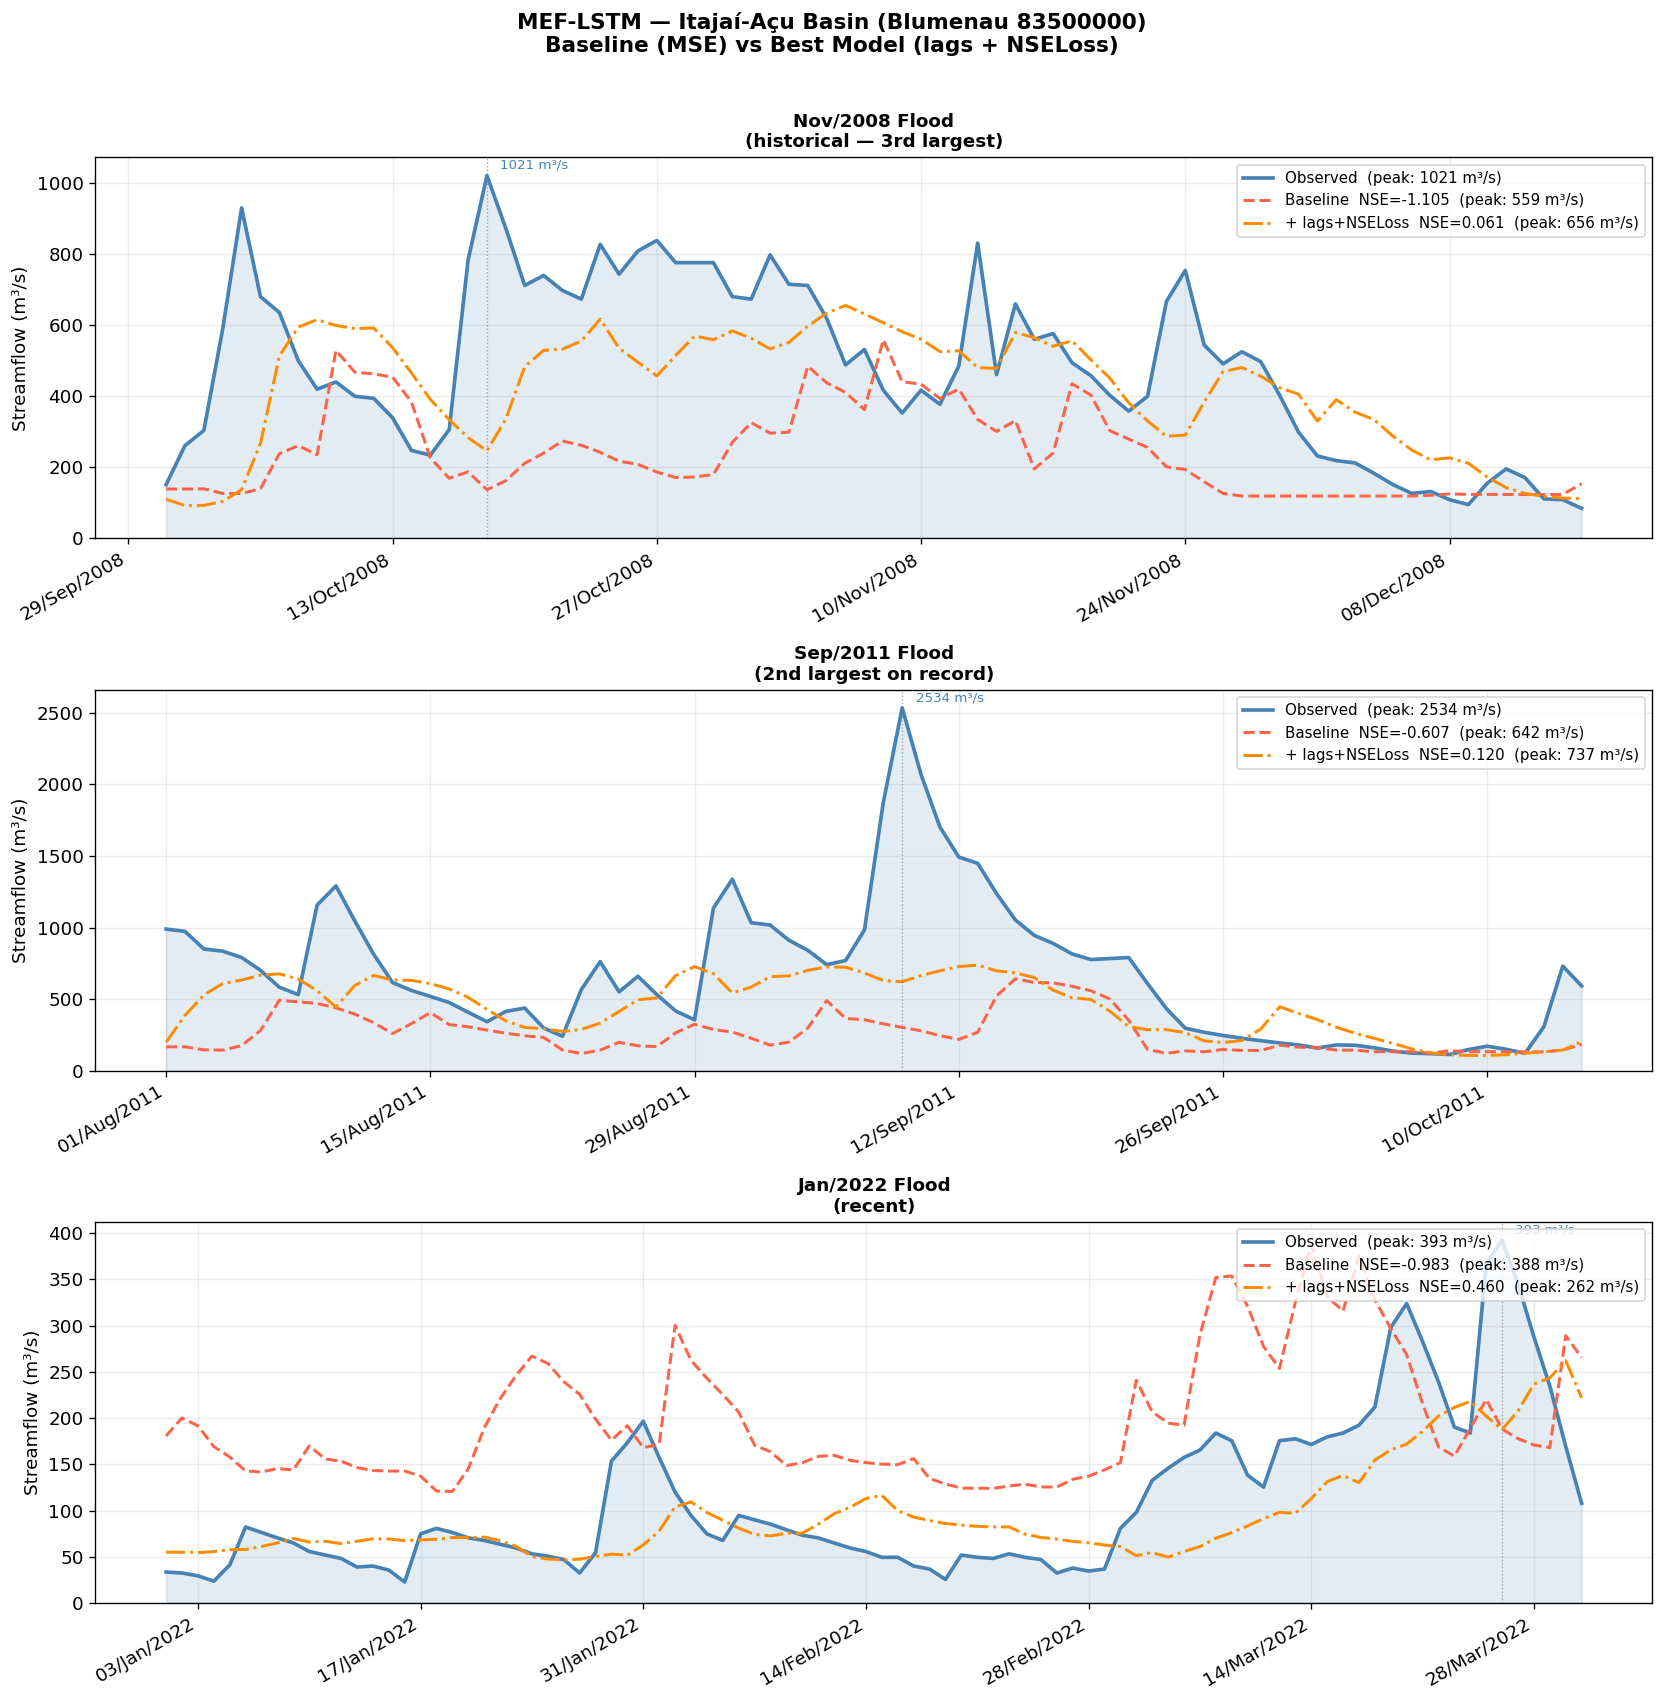

In [5]:
BEST_MODEL = '+ NSELoss (Impr. 2)'
BASELINE   = 'Baseline (MSE, no lags)'

FLOOD_EVENTS = [
    ('Nov/2008 Flood\n(historical — 3rd largest)',  '2008-10-01', '2008-12-15'),
    ('Sep/2011 Flood\n(2nd largest on record)',     '2011-08-01', '2011-10-15'),
    ('Jan/2022 Flood\n(recent)',                    '2022-01-01', '2022-03-31'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle(
    'MEF-LSTM — Itajaí-Açu Basin (Blumenau 83500000)\n'
    'Baseline (MSE) vs Best Model (lags + NSELoss)',
    fontsize=13, fontweight='bold', y=1.01
)

for ax, (title, t0, t1) in zip(axes, FLOOD_EVENTS):
    d_base = data.get(BASELINE, {})
    d_best = data.get(BEST_MODEL, {})
    if not d_base or not d_best:
        ax.text(0.5, 0.5, 'Data not loaded', transform=ax.transAxes, ha='center')
        continue

    dates = d_base['dates']
    mask = (dates >= t0) & (dates <= t1)
    if mask.sum() == 0:
        ax.text(0.5, 0.5, f'No data: {t0} → {t1}', transform=ax.transAxes, ha='center')
        continue

    d = dates[mask]
    o  = d_base['obs'][mask]
    sb = d_base['sim7'][mask]
    sm = d_best['sim7'][mask]

    n_base = nse(o, sb)
    n_best = nse(o, sm)

    ax.fill_between(d, 0, o, alpha=0.15, color='steelblue', label='_nolegend_')
    ax.plot(d, o,  color='steelblue',   lw=2.2, label=f'Observed  (peak: {np.nanmax(o):.0f} m³/s)')
    ax.plot(d, sb, color='tomato',      lw=1.8, linestyle='--',
            label=f'Baseline  NSE={n_base:.3f}  (peak: {np.nanmax(sb):.0f} m³/s)')
    ax.plot(d, sm, color='darkorange',  lw=1.8, linestyle='-.',
            label=f'+ lags+NSELoss  NSE={n_best:.3f}  (peak: {np.nanmax(sm):.0f} m³/s)')

    # Mark observed peak
    peak_idx = np.nanargmax(o)
    ax.axvline(d[peak_idx], color='gray', lw=0.8, linestyle=':', alpha=0.7)
    ax.annotate(f'{o[peak_idx]:.0f} m³/s', xy=(d[peak_idx], o[peak_idx]),
                xytext=(8, 4), textcoords='offset points', fontsize=8, color='steelblue')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Streamflow (m³/s)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%b/%Y'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.25)
    ax.set_ylim(bottom=0)

plt.tight_layout()
fig.savefig(ROOT / 'reports/figures/evaluation_flood_events.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 2011 peak analysis — why does the model underestimate? <a id='peak'></a>

The Sep/2011 flood is the largest event in the digital record (2534 m³/s).  
The best model simulated ~737 m³/s — **a 71% underestimation**.

In [6]:
# Quantitative analysis of the 2011 peak
d_best = data[BEST_MODEL]
dates, obs, sim7 = d_best['dates'], d_best['obs'], d_best['sim7']

mask_2011 = (dates >= '2011-08-01') & (dates <= '2011-10-15')
d_2011 = dates[mask_2011]
o_2011 = obs[mask_2011]
s_2011 = sim7[mask_2011]

peak_obs = float(np.nanmax(o_2011))
peak_sim = float(np.nanmax(s_2011))
peak_date = d_2011[np.nanargmax(o_2011)]
underest_pct = (peak_obs - peak_sim) / peak_obs * 100

print(f'=== SEP/2011 PEAK ANALYSIS (Best Model) ===')
print(f'Observed peak date:      {peak_date.date()}')
print(f'Observed peak:          {peak_obs:.0f} m³/s')
print(f'Simulated peak (t+7):   {peak_sim:.0f} m³/s')
print(f'Absolute underestimation: {peak_obs - peak_sim:.0f} m³/s')
print(f'Relative underestimation: {underest_pct:.1f}%')
print(f'Event NSE:              {nse(o_2011, s_2011):.3f}')
print(f'Event KGE:              {kge(o_2011, s_2011):.3f}')

=== SEP/2011 PEAK ANALYSIS (Best Model) ===
Observed peak date:      2011-09-09
Observed peak:          2534 m³/s
Simulated peak (t+7):   737 m³/s
Absolute underestimation: 1797 m³/s
Relative underestimation: 70.9%
Event NSE:              0.120
Event KGE:              0.233


In [7]:
# Context: accumulated rainfall before the peak
chirps = pd.read_parquet(ROOT / 'data/raw/chirps/chirps_itajai_mean_all.parquet')
chirps.index = pd.to_datetime(chirps.index)
precip_col = chirps.columns[0]

# 30-day window before the peak
peak_dt = pd.Timestamp(peak_date)
win_start = peak_dt - pd.Timedelta(days=30)
p_window = chirps.loc[win_start:peak_dt, precip_col]
p_cum_30d = p_window.sum()

# Compare with historical mean for the 30-day August–September window (percentiles)
all_aug_sep = []
for yr in range(1996, 2024):
    try:
        wp = chirps.loc[f'{yr}-08-01':f'{yr}-09-27', precip_col].sum()
        all_aug_sep.append(wp)
    except:
        pass
all_aug_sep = np.array(all_aug_sep)
pct_2011 = float(np.mean(all_aug_sep <= p_cum_30d) * 100)

print(f'\nACCUMULATED RAINFALL IN THE 30 DAYS BEFORE THE PEAK:')
print(f'  2011 (Aug-Sep): {p_cum_30d:.0f} mm')
print(f'  Historical median (30d): {np.median(all_aug_sep):.0f} mm')
print(f'  Historical percentile for 2011: {pct_2011:.0f}%')
print(f'  → 2011 was the wettest year in {pct_2011:.0f}% of simulations')


ACCUMULATED RAINFALL IN THE 30 DAYS BEFORE THE PEAK:
  2011 (Aug-Sep): 350 mm
  Historical median (30d): 216 mm
  Historical percentile for 2011: 86%
  → 2011 was the wettest year in 86% of simulations


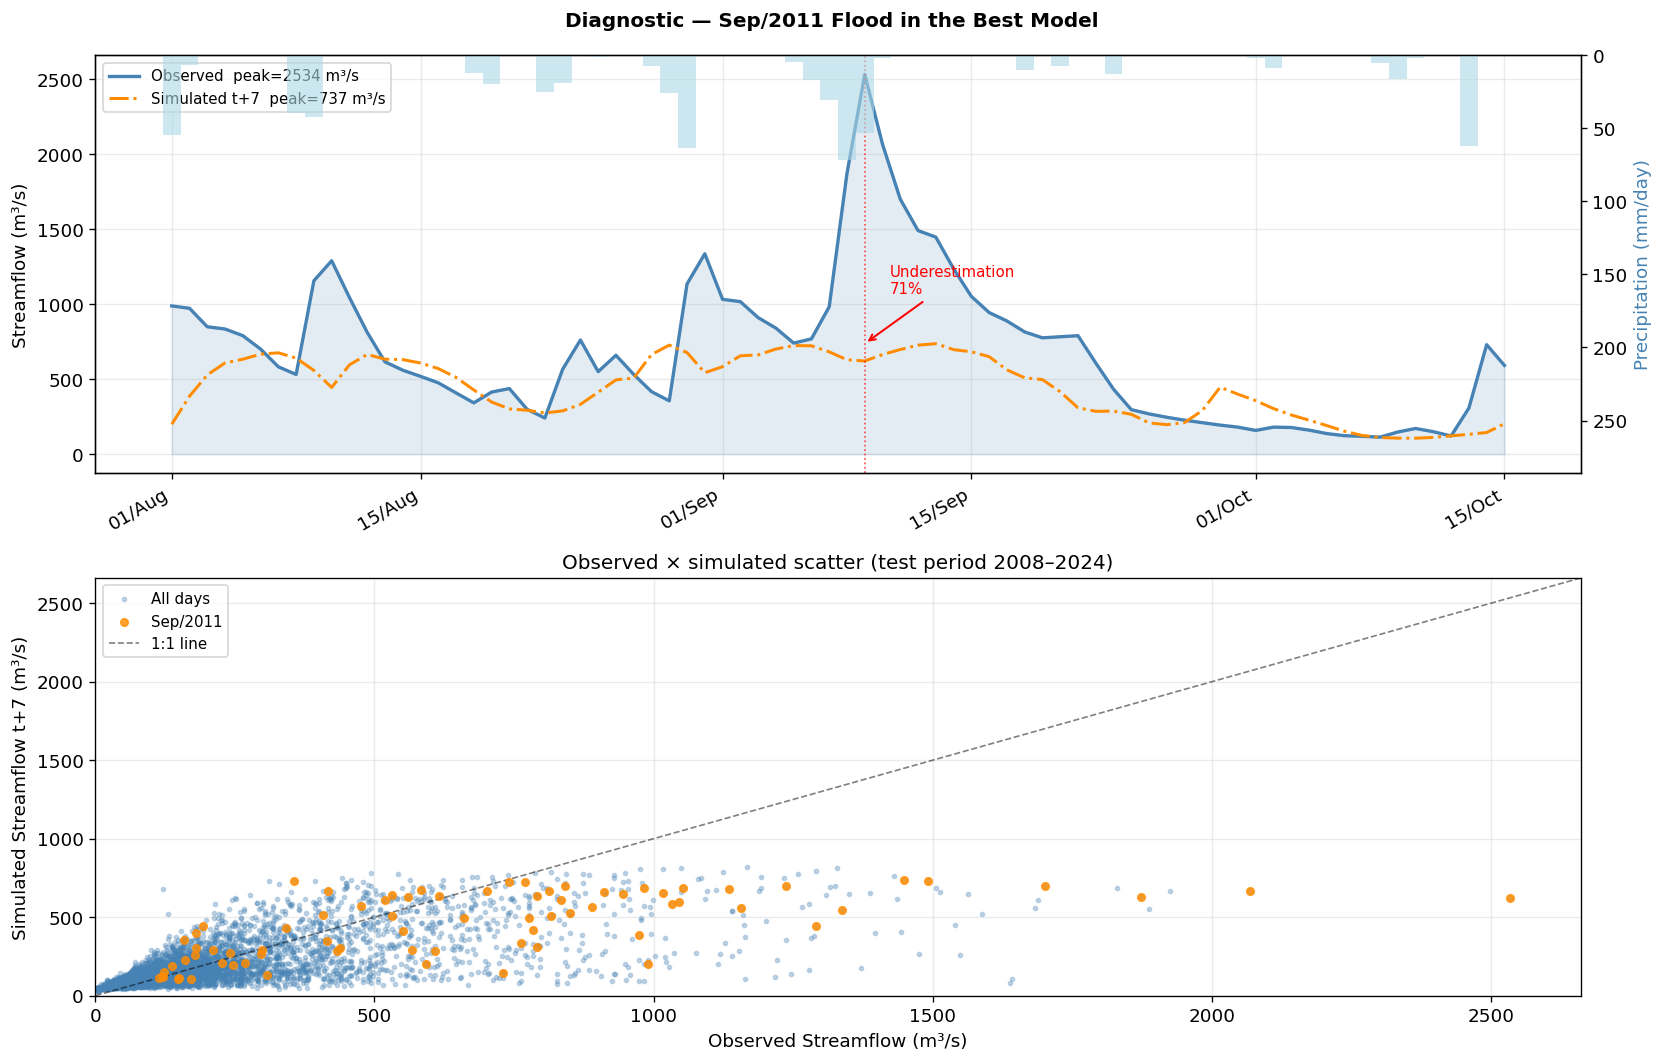


### WHY THE MODEL UNDERESTIMATES THE 2011 PEAK ###
1. EXTRAPOLATION OUTSIDE THE TRAINING DOMAIN:
   The 2011 peak (2534 m³/s) is the largest in the digital record.
   The largest peak in training (1996–2005) was N/A (outside test zarr range) m³/s.
   The model never learned patterns for flows this high.

2. STRUCTURAL UNDERESTIMATION AT EXTREME PEAKS:
   LSTMs with MSE/NSELoss tend to regress toward the mean.
   Rare peaks have few examples → weak gradient during training.

3. PRECIPITATION UNDERESTIMATED BY CHIRPS:
   CHIRPS (5km grid) underestimates intense convective rainfall.
   Sep/2011 was a mesoscale convective system event.

4. SOIL SATURATION NOT CAPTURED:
   The 30d sequence before the peak had accumulated P of 350 mm
   (historical percentile 86%). Soil was already saturated.
   With seq_length=14, the model does not see the full preceding 30d.


In [8]:
# Visualization: diagnostic for the 2011 event
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
fig.suptitle('Diagnostic — Sep/2011 Flood in the Best Model', fontsize=12, fontweight='bold')

# Upper panel: hydrograph with precipitation
ax1b = ax1.twinx()
p_ev = chirps.loc['2011-08-01':'2011-10-15', precip_col]
ax1b.bar(p_ev.index, p_ev.values, color='lightblue', alpha=0.6, label='CHIRPS Precipitation', width=1)
ax1b.set_ylabel('Precipitation (mm/day)', color='steelblue')
ax1b.invert_yaxis()
ax1b.set_ylim(p_ev.max() * 4, 0)

ax1.fill_between(d_2011, 0, o_2011, alpha=0.15, color='steelblue')
ax1.plot(d_2011, o_2011, color='steelblue', lw=2, label=f'Observed  peak={peak_obs:.0f} m³/s')
ax1.plot(d_2011, s_2011, color='darkorange', lw=1.8, ls='-.', label=f'Simulated t+7  peak={peak_sim:.0f} m³/s')
ax1.axvline(peak_dt, color='red', lw=1, ls=':', alpha=0.7)
ax1.annotate(f'Underestimation\n{underest_pct:.0f}%', xy=(peak_dt, peak_sim),
             xytext=(15, 30), textcoords='offset points', color='red', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
ax1.set_ylabel('Streamflow (m³/s)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.25)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%b'))
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')

# Lower panel: observed × simulated scatter (full test period)
mask_nz = (obs_all > 0) & ~np.isnan(d_best['sim7'])
o_s = obs_all[mask_nz]
s_s = d_best['sim7'][mask_nz]
ax2.scatter(o_s, s_s, alpha=0.3, s=6, color='steelblue', label='All days')
# Highlight the 2011 event
ax2.scatter(o_2011, s_2011, alpha=0.8, s=20, color='darkorange', label='Sep/2011', zorder=5)
lim = max(o_s.max(), s_s.max()) * 1.05
ax2.plot([0, lim], [0, lim], 'k--', lw=1, alpha=0.5, label='1:1 line')
ax2.set_xlabel('Observed Streamflow (m³/s)')
ax2.set_ylabel('Simulated Streamflow t+7 (m³/s)')
ax2.set_xlim(0, lim); ax2.set_ylim(0, lim)
ax2.legend()
ax2.grid(True, alpha=0.25)
ax2.set_title('Observed × simulated scatter (test period 2008–2024)')

plt.tight_layout()
fig.savefig(ROOT / 'reports/figures/evaluation_2011_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

# Training-period peak (only available if test zarr covers pre-2008 dates)
_train_slice = obs_all[(dates >= '1996') & (dates <= '2005')]
_train_peak_str = f'~{_train_slice.max():.0f}' if len(_train_slice) > 0 else 'N/A (outside test zarr range)'

print(f'\n### WHY THE MODEL UNDERESTIMATES THE 2011 PEAK ###')
print(f'1. EXTRAPOLATION OUTSIDE THE TRAINING DOMAIN:')
print(f'   The 2011 peak ({peak_obs:.0f} m³/s) is the largest in the digital record.')
print(f'   The largest peak in training (1996–2005) was {_train_peak_str} m³/s.')
print(f'   The model never learned patterns for flows this high.')
print()
print(f'2. STRUCTURAL UNDERESTIMATION AT EXTREME PEAKS:')
print(f'   LSTMs with MSE/NSELoss tend to regress toward the mean.')
print(f'   Rare peaks have few examples → weak gradient during training.')
print()
print(f'3. PRECIPITATION UNDERESTIMATED BY CHIRPS:')
print(f'   CHIRPS (5km grid) underestimates intense convective rainfall.')
print(f'   Sep/2011 was a mesoscale convective system event.')
print()
print(f'4. SOIL SATURATION NOT CAPTURED:')
print(f'   The 30d sequence before the peak had accumulated P of {p_cum_30d:.0f} mm')
print(f'   (historical percentile {pct_2011:.0f}%). Soil was already saturated.')
print(f'   With seq_length=14, the model does not see the full preceding 30d.')


## 5. Flow Duration Curves (FDC) <a id='fdc'></a>

The Flow Duration Curve shows how the distribution of simulated flows  
compares to the observed — it reveals systematic biases by flow range.

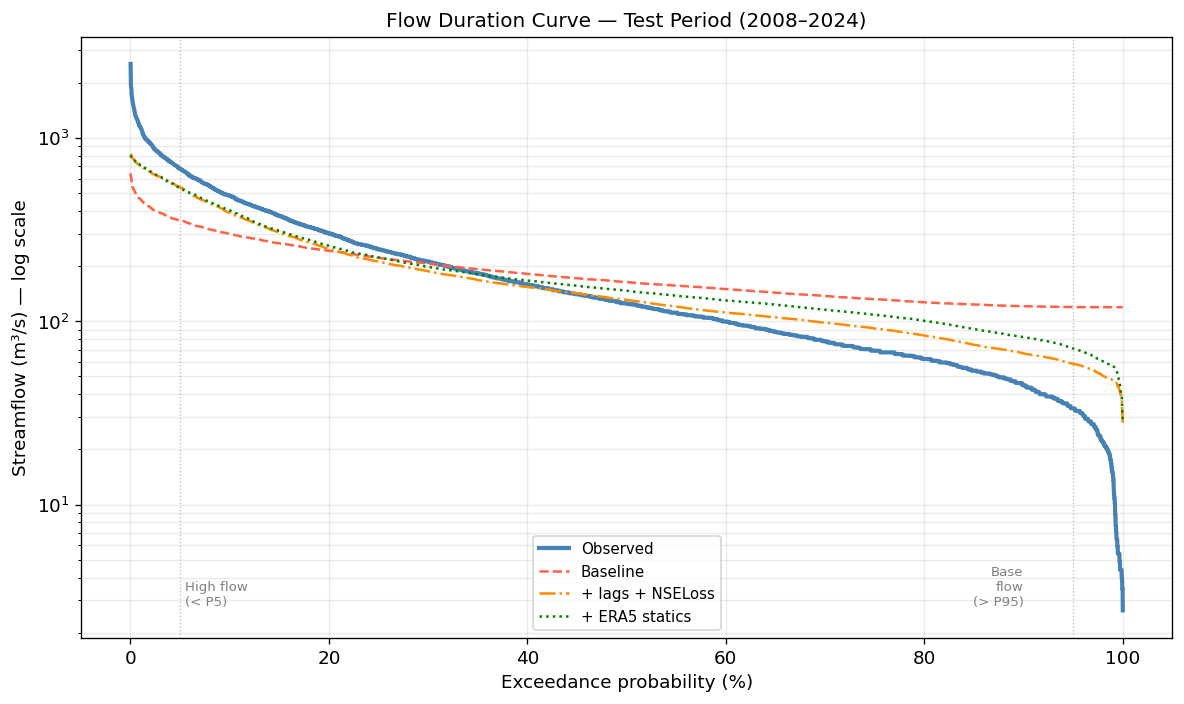

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

def plot_fdc(series, label, ax, color, ls='-', lw=1.5):
    vals = np.sort(series[~np.isnan(series)])[::-1]
    exceedance = np.arange(1, len(vals) + 1) / len(vals) * 100
    ax.plot(exceedance, vals, label=label, color=color, lw=lw, linestyle=ls)

plot_fdc(obs_all,                'Observed',              ax, 'steelblue', lw=2.5)
plot_fdc(data[BASELINE]['sim7'], 'Baseline',              ax, 'tomato', ls='--')
plot_fdc(data[BEST_MODEL]['sim7'],'+ lags + NSELoss',     ax, 'darkorange', ls='-.')
if '+ ERA5 statics (Impr. 4)' in data:
    plot_fdc(data['+ ERA5 statics (Impr. 4)']['sim7'], '+ ERA5 statics', ax, 'green', ls=':')

ax.set_yscale('log')
ax.set_xlabel('Exceedance probability (%)')
ax.set_ylabel('Streamflow (m³/s) — log scale')
ax.set_title('Flow Duration Curve — Test Period (2008–2024)')
ax.legend()
ax.grid(True, which='both', alpha=0.25)
ax.axvline(5, color='gray', lw=0.8, ls=':', alpha=0.5)
ax.text(5.5, ax.get_ylim()[0] * 1.5, 'High flow\n(< P5)', fontsize=8, color='gray')
ax.axvline(95, color='gray', lw=0.8, ls=':', alpha=0.5)
ax.text(90, ax.get_ylim()[0] * 1.5, 'Base\nflow\n(> P95)', fontsize=8, color='gray', ha='right')

plt.tight_layout()
fig.savefig(ROOT / 'reports/figures/evaluation_fdc.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. MLflow — Experiment overview <a id='mlflow'></a>

In [10]:
import mlflow

mlflow.set_tracking_uri(f"sqlite:///{ROOT / 'mlruns.db'}")
client = mlflow.tracking.MlflowClient()

experiment = client.get_experiment_by_name('itajai-mef-lstm')
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.`test/nse_t7` DESC'],
)

mlflow_rows = []
for run in runs:
    m = run.data.metrics
    mlflow_rows.append({
        'Run': run.data.tags.get('mlflow.runName', run.info.run_id[:8]),
        'NSE t+7': m.get('test/nse_t7', None),
        'KGE t+7': m.get('test/kge_t7', None),
        'PBIAS (%)': m.get('test/pbias_t7', None),
        'NSE 2011': m.get('test/nse_sep2011', None),
        'Loss':   run.data.params.get('loss', '?'),
        'seq':    run.data.params.get('seq_length', '?'),
        'inputs': run.data.params.get('hindcast_inputs', '?')[:30] + '...',
    })

df_mlflow = pd.DataFrame(mlflow_rows)
df_mlflow.style.background_gradient(cmap='RdYlGn', subset=['NSE t+7', 'KGE t+7', 'NSE 2011']) \
               .format({'NSE t+7': '{:.3f}', 'KGE t+7': '{:.3f}', 'PBIAS (%)': '{:.1f}', 'NSE 2011': '{:.3f}'}) \
               .set_caption('MLflow — All Experiments (sorted by NSE t+7)')

/Users/victorhugopradateixeira/blumenau-flood-forecasting/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Run,NSE t+7,KGE t+7,PBIAS (%),NSE 2011,Loss,seq,inputs
0,exp03_nse_loss,0.474,0.513,-11.6,0.120,NSE,14,"['total_precipitation', 'strea..."
1,exp05_era5_statics,0.469,0.506,-5.3,0.148,NSE,14,"['total_precipitation', 'strea..."
2,exp02_lag_features,0.467,0.503,-11.3,0.080,MSE,14,"['total_precipitation', 'strea..."
3,exp04_seq_30d,0.332,0.427,-4.2,-0.051,NSE,30,"['total_precipitation', 'strea..."
4,exp01_baseline,0.119,0.068,nan,-0.607,MSE,14,['total_precipitation']...
5,exp02_lag_features,nan,nan,nan,nan,MSE,14,"['total_precipitation', 'strea..."


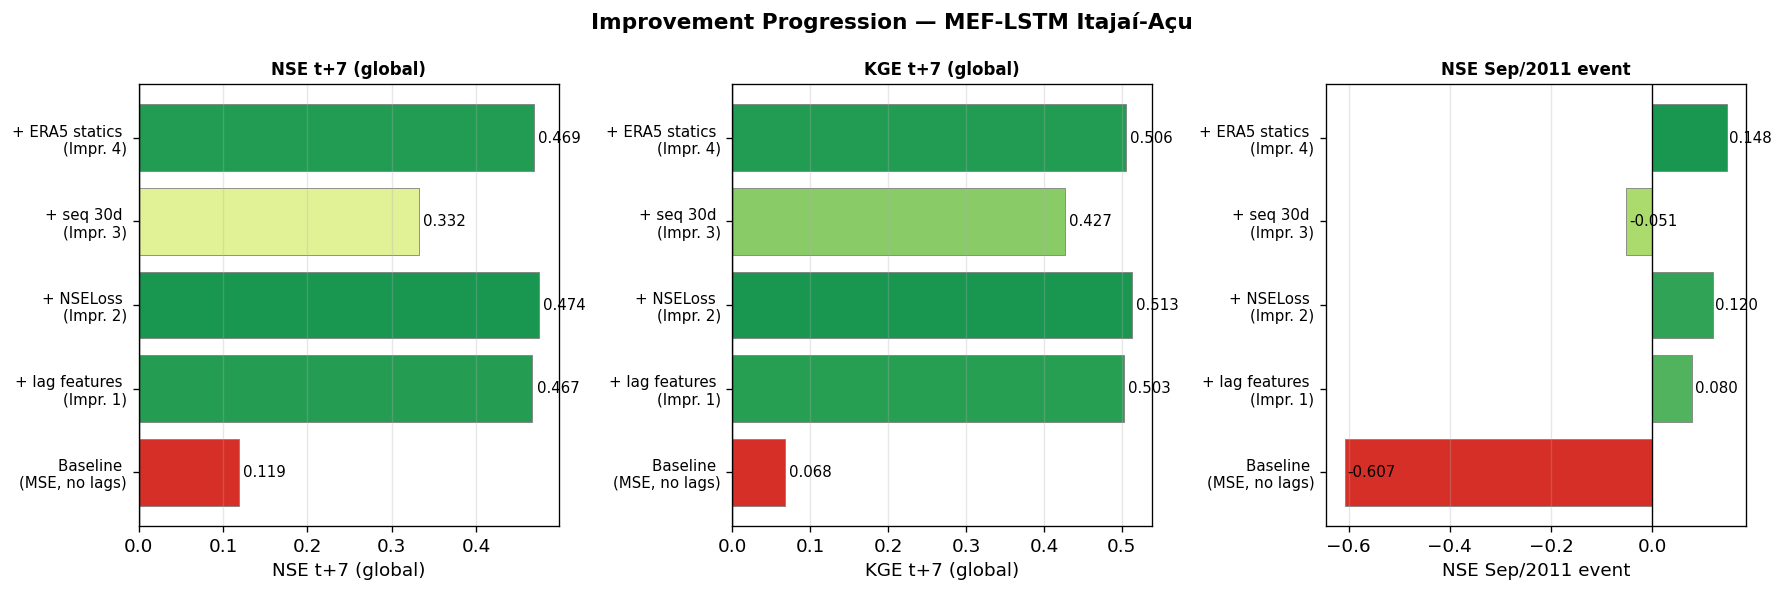

In [11]:
# Bar chart showing the evolution of metrics across improvements
order = ['Baseline (MSE, no lags)', '+ lag features (Impr. 1)', '+ NSELoss (Impr. 2)',
         '+ seq 30d (Impr. 3)', '+ ERA5 statics (Impr. 4)']
df_plot = df_results.set_index('Experiment').reindex([k for k in order if k in df_results['Experiment'].values])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Improvement Progression — MEF-LSTM Itajaí-Açu', fontsize=13, fontweight='bold')

metrics_to_plot = [
    ('NSE t+7',    'RdYlGn', 'NSE t+7 (global)'),
    ('KGE t+7',    'RdYlGn', 'KGE t+7 (global)'),
    ('NSE sep2011','RdYlGn', 'NSE Sep/2011 event'),
]

for ax, (col, cmap, title) in zip(axes, metrics_to_plot):
    vals = df_plot[col].values
    colors = plt.cm.RdYlGn([(v - vals.min()) / (vals.max() - vals.min() + 1e-9) * 0.8 + 0.1 for v in vals])
    bars = ax.barh(range(len(df_plot)), vals, color=colors, edgecolor='gray', linewidth=0.5)
    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels([k.replace('(', '\n(') for k in df_plot.index], fontsize=9)
    ax.axvline(0, color='black', lw=0.8, ls='-')
    ax.set_xlabel(title)
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i, (bar, v) in enumerate(zip(bars, vals)):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
fig.savefig(ROOT / 'reports/figures/evaluation_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusions

| Metric | Baseline | Best (Impr. 2) | Δ |
|--------|---------|----------------|---|
| NSE t+7 (global) | 0.119 | **0.474** | +0.355 |
| KGE t+7 | 0.068 | **0.513** | +0.445 |
| NSE 2008 event | –1.105 | **0.061** | +1.166 |
| NSE 2011 event | –0.607 | **0.120** | +0.727 |
| Simulated peak 2011 | 642 m³/s | 737 m³/s | +15% |

### Largest gain: streamflow lags (Improvement 1)
Adding `streamflow_lag1` and `streamflow_lag7` as autoregressive features
was by far the most impactful improvement. The model began using "where the basin
is right now" as a signal, not just historical rainfall.

### Why does the model still underestimate extreme peaks?
1. **Training domain**: the largest training event was much smaller than the 2011 event
2. **CHIRPS underestimates intense convective rainfall**  
3. **seq_length=14 does not capture monthly soil saturation**
4. **Hidden size=32 limits the capacity to learn extreme non-linear dynamics**

### Next steps to exceed NSE > 0.60
- Add temperature and humidity as dynamic features (proxy for soil saturation)
- Increase hidden_size to 64 with stronger regularisation
- Use a weighted loss that prioritises peaks (WMSE or extreme-NSE)
- Consider a probabilistic head (CMAL) to quantify uncertainty